# Tarea 6

In [37]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import sys
import os

import yfinance as yf

from scipy.optimize import minimize

from portfolio_utils import PortfolioElementaryMetrics

In [ ]:

load_dotenv()
sys.path.insert(0, os.path.join(os.environ["PORTFOLIO_ROOT"], "src"))

## A) Implementación de funciones

Punto a) Implementen tres funciones que optimicen portafolios utilizando: mínima semivarianza, ratio omega y semivarianza objetivo, empleando la función `scipy.optimize.minimize`. (40%)

In [84]:
# function aux
OPTIMIZATION_TOL = 1e-50

def portfolio_var(weight : np.ndarray, cov_matrix):
    return weight.T @ cov_matrix @ weight

def weight_sum(weight : np.ndarray):
    assets = len(weight)
    return weight @ np.ones(assets) - 1

def _asset_returns(prices : pd.DataFrame) -> pd.DataFrame:
    return prices.pct_change().dropna()

def _initial_weight(n_assets : int) -> np.ndarray:
    return np.ones(n_assets) / n_assets

def _weight_bounds(n_assets : int):
    return [(0, 1)] * n_assets

def _optimize_weights(objective, n_assets : int) -> np.ndarray:
    opt = minimize(
        fun=objective,
        x0=_initial_weight(n_assets),
        bounds=_weight_bounds(n_assets),
        constraints={"fun": weight_sum, "type": "eq"},
        tol=OPTIMIZATION_TOL
    )
    print(opt)
    return opt.x

def _build_semivariance_matrix(
    downside_risk : np.ndarray,
    corr : pd.DataFrame,
    n_assets : int,
):
    return downside_risk.reshape(n_assets, 1) @ downside_risk.reshape(1, n_assets) * corr



In [107]:
def min_semivar(prices : pd.DataFrame, umbral : float = 0) -> np.ndarray:
    returns = _asset_returns(prices)
    n_assets = len(returns.columns)
    corr = returns.corr()

    below_threshold = returns[returns < umbral].fillna(0)
    downside_risk = np.array(below_threshold.std())
    semivar_matrix = _build_semivariance_matrix(downside_risk, corr, n_assets)

    return _optimize_weights(
        objective=lambda weight: portfolio_var(weight, semivar_matrix),
        n_assets=n_assets,
    )


def ratio_omega(prices : pd.DataFrame, umbral : float = 0) -> np.ndarray:
    returns = _asset_returns(prices)
    n_assets = len(returns.columns)

    below_threshold = returns[returns < umbral].fillna(0)
    above_threshold = returns[returns > umbral].fillna(0)

    downside_risk = np.array(below_threshold.std())
    upside_risk = np.array(above_threshold.std())
    omega = upside_risk / downside_risk

    return _optimize_weights(
        objective=lambda weight: (-1) * (omega @ weight),
        n_assets=n_assets,
    )


def target_semivar(prices : pd.DataFrame, benchmark : pd.DataFrame = None, umbral : float = 0):
    returns_assets = _asset_returns(prices)
    n_assets = len(returns_assets.columns)
    corr = returns_assets.corr()

    if umbral != 0 and type(umbral) is float:
        diff = returns_assets - umbral
    elif benchmark is not None:
        returns_benchmark = _asset_returns(benchmark)
        diff = returns_assets - returns_benchmark.values
    else:
        return None

    below_target = diff[diff < 0].fillna(0)
    target_downside = np.array(below_target.std())
    target_semivar_matrix = _build_semivariance_matrix(target_downside, corr, n_assets)

    return _optimize_weights(
        objective=lambda weight: portfolio_var(weight, target_semivar_matrix),
        n_assets=n_assets,
    )

In [105]:
# Descarga de Datos
tickets = ['PG', 'COST', 'KO', 'WMT', 'CLX', 'KHC']
benchmark = ["KXI"]
start = '2020-01-01'
end = '2026-03-06'

prices=yf.download(tickets, 
                    start=start, end=end)['Close']

benchmark_price = yf.download(benchmark, start=start, end=end)["Close"]

[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  1 of 1 completed


In [92]:
result = min_semivar(prices)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 4.296206478644753e-05
           x: [ 1.337e-01  1.390e-01  4.773e-02  3.178e-01  1.186e-01
                2.432e-01]
         nit: 38
         jac: [ 8.592e-05  8.592e-05  8.592e-05  8.592e-05  8.592e-05
                8.592e-05]
        nfev: 268
        njev: 38
 multipliers: [ 8.592e-05]


In [93]:
dict(zip(prices.columns, result))

{'CLX': np.float64(0.13366043280081347),
 'COST': np.float64(0.13899797449740547),
 'KHC': np.float64(0.04773474014977141),
 'KO': np.float64(0.3177974596885635),
 'PG': np.float64(0.11863469965482458),
 'WMT': np.float64(0.2431746932086216)}

In [94]:
result = ratio_omega(prices)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -1.0898633700923899
           x: [ 2.076e-17  0.000e+00  6.878e-18  0.000e+00  0.000e+00
                1.000e+00]
         nit: 8
         jac: [-9.417e-01 -1.030e+00 -9.863e-01 -9.494e-01 -9.758e-01
               -1.090e+00]
        nfev: 50
        njev: 7
 multipliers: [-1.030e+00]


In [95]:
dict(zip(prices.columns, result))

{'CLX': np.float64(2.0755990274657934e-17),
 'COST': np.float64(0.0),
 'KHC': np.float64(6.8782024668434894e-18),
 'KO': np.float64(0.0),
 'PG': np.float64(0.0),
 'WMT': np.float64(1.0)}

In [110]:
weight_target_semivar = target_semivar(prices, benchmark=benchmark_price)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 2.010555713296933e-05
           x: [ 7.182e-03  7.394e-02  7.250e-20  5.005e-01  3.351e-01
                8.326e-02]
         nit: 62
         jac: [ 4.021e-05  4.021e-05  4.349e-05  4.021e-05  4.021e-05
                4.021e-05]
        nfev: 439
        njev: 62
 multipliers: [ 4.021e-05]


In [111]:
dict(zip(prices.columns, weight_target_semivar))

{'CLX': np.float64(0.0071822683774909225),
 'COST': np.float64(0.07393811490374741),
 'KHC': np.float64(7.249952444885645e-20),
 'KO': np.float64(0.5005035117187275),
 'PG': np.float64(0.3351194936962645),
 'WMT': np.float64(0.08325661130376966)}

In [112]:
portfolio_min_semivar = PortfolioElementaryMetrics(start=start, tickers=tickets, end=end, weight=result)
portfolio_target_min_semivar = PortfolioElementaryMetrics(start=start, tickers=tickets, end=end, weight=weight_target_semivar)


In [50]:
portfolio_min_semivar.annual_return(), portfolio_min_semivar.annual_volatility()

(Ticker
 CLX     0.018509
 COST    0.240574
 KHC     0.039094
 KO      0.105325
 PG      0.082730
 WMT     0.225074
 dtype: float64,
 Ticker
 CLX     0.265109
 COST    0.237059
 KHC     0.268217
 KO      0.202481
 PG      0.206315
 WMT     0.231649
 dtype: float64)

In [51]:
portfolio_min_semivar.portfolio_annual_return()

0.13579823881000522

In [113]:
portfolio_target_min_semivar.portfolio_annual_return()

0.11709936400317392

In [114]:
portfolio_target_min_semivar.portfolio_annual_volatility()

0.17582445259491616

In [52]:
portfolio_min_semivar.portfolio_annual_volatility()

0.16741121173738502

In [80]:
portfolio_min_semivar.skew()

Ticker
CLX    -0.282411
COST   -0.142653
KHC     0.404551
KO     -0.536551
PG      0.059521
WMT     0.204339
dtype: float64

In [74]:
path = portfolio_min_semivar.portfolio_path() 
path[path.index <= "2026-01-02"] 

Date
2020-01-02     90.774143
2020-01-03     90.583493
2020-01-06     90.641012
2020-01-07     90.090408
2020-01-08     90.607177
                 ...    
2025-12-26    201.661716
2025-12-29    201.266614
2025-12-30    200.934012
2025-12-31    200.207062
2026-01-02    199.027901
Length: 1509, dtype: float64

In [116]:
path_target = portfolio_target_min_semivar.portfolio_path()
path_target[path_target.index <= "2026-01-02"]

Date
2020-01-02     81.718616
2020-01-03     81.347925
2020-01-06     81.390379
2020-01-07     80.929091
2020-01-08     81.337396
                 ...    
2025-12-26    157.383368
2025-12-29    157.135292
2025-12-30    156.715825
2025-12-31    156.103331
2026-01-02    154.738491
Length: 1509, dtype: float64

In [69]:
index = portfolio_min_semivar.get_prices()
index

Ticker,CLX,COST,KHC,KO,PG,WMT
Date,,,,,,
2020-01-02,126.064575,266.133942,23.362873,45.432705,105.524025,36.433842
2020-01-03,126.312378,266.353119,23.089405,45.184845,104.814301,36.112202
2020-01-06,126.692352,266.426086,23.141144,45.168324,104.959679,36.038685
2020-01-07,125.164192,266.006104,22.734638,44.821316,104.309814,35.704796
2020-01-08,125.535889,269.055603,22.608997,44.903942,104.754456,35.582260
...,...,...,...,...,...,...
2026-02-27,127.160004,1010.789978,24.203728,81.003021,167.199997,127.949997
2026-03-02,126.809998,1002.770020,24.105377,79.672180,163.509995,127.099998
2026-03-03,121.150002,1007.770020,23.820164,78.798180,159.720001,127.910004


In [120]:
prices_portfolio = pd.concat([path, path_target, benchmark_price], axis = 1)

<Axes: xlabel='Date'>

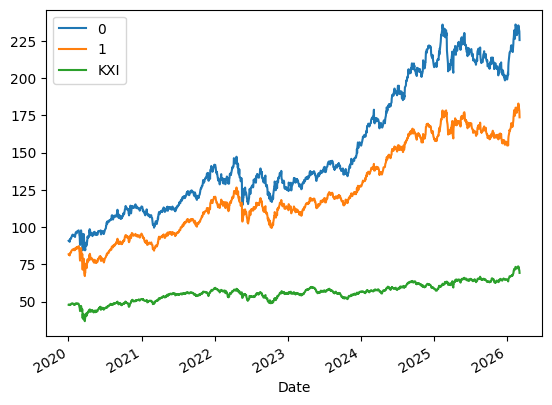

In [121]:
prices_portfolio.plot()

In [76]:
portfolio_return = path.pct_change().dropna()
portfolio_return.mean() * 252 * 100

np.float64(16.51618525229793)

In [ ]:
portfolio_return.std() * np.sqrt(252) * 100

np.float64(18.551571993116635)

<Axes: xlabel='Ticker', ylabel='Ticker'>

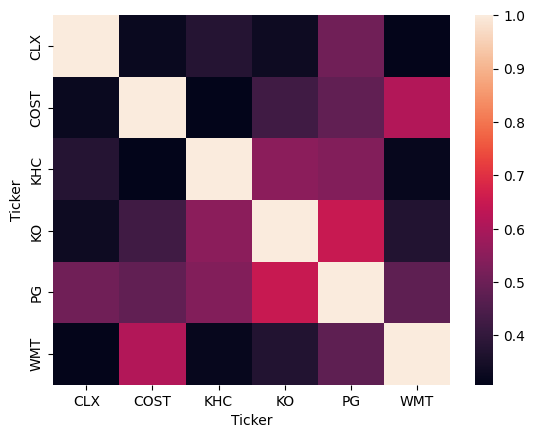